In [2]:
import pandas as pd

# Lecture du fichier
df_raw = pd.read_excel('Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx', header=None)

# Trouver la colonne FR diesel
header_row = df_raw.iloc[0]
fr_diesel_col = header_row[header_row == 'FR_price_with_tax_diesel'].index[0]

# Extraire date + colonne FR diesel (données à partir de la ligne 3)
df = df_raw.iloc[3:, [0, fr_diesel_col]].copy()
df.columns = ['date', 'prix_diesel_france']

# Nettoyage
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['prix_diesel_france'] = pd.to_numeric(df['prix_diesel_france'], errors='coerce')
df = df.dropna().sort_values('date').reset_index(drop=True)

# Conversion €/1000L → €/L
df['prix_diesel_france_eur_L'] = df['prix_diesel_france'] / 1000

# Filtre 2007-2026
df = df[(df['date'].dt.year >= 2007) & (df['date'].dt.year <= 2026)]

df[['date', 'prix_diesel_france_eur_L']].to_csv('prix_diesel_france.csv', index=False)

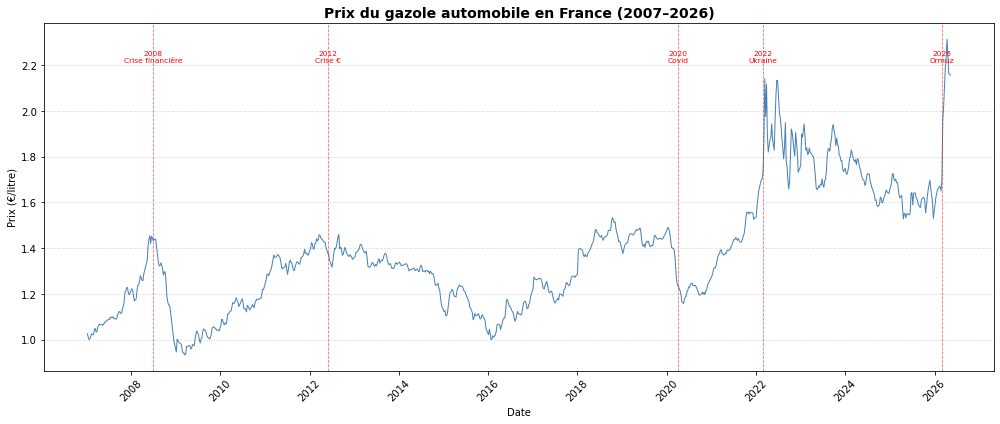

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Chargement
df = pd.read_csv('prix_diesel_france.csv', parse_dates=['date'])

# Graphique
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['date'], df['prix_diesel_france_eur_L'], color='steelblue', linewidth=1)

# Annotations des événements clés
evenements = {
    '2008\nCrise financière': '2008-07-01',
    '2012\nCrise €': '2012-06-01',
    '2020\nCovid': '2020-04-01',
    '2022\nUkraine': '2022-03-01',
    '2026\nOrmuz': '2026-03-01',
}

for label, date in evenements.items():
    ax.axvline(pd.to_datetime(date), color='red', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pd.to_datetime(date), ax.get_ylim()[1] * 0.95, label,
            fontsize=7.5, color='red', ha='center', va='top')

# Mise en forme
ax.set_title('Prix du gazole automobile en France (2007–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix (€/litre)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

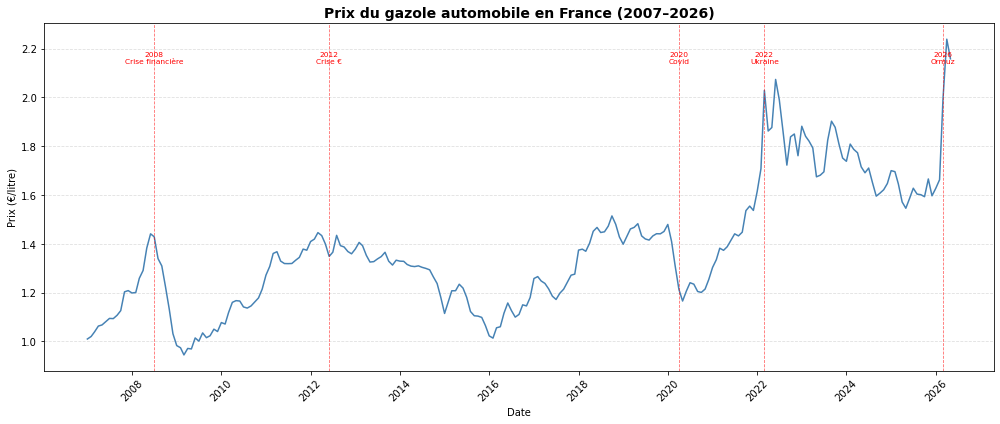

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Chargement
df = pd.read_csv('prix_diesel_france.csv', parse_dates=['date'])

# Moyenne mensuelle
df['mois'] = df['date'].dt.to_period('M')
df_mensuel = df.groupby('mois')['prix_diesel_france_eur_L'].mean().reset_index()
df_mensuel['date'] = df_mensuel['mois'].dt.to_timestamp()

# Graphique
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_mensuel['date'], df_mensuel['prix_diesel_france_eur_L'], color='steelblue', linewidth=1.5)

# Annotations des événements clés
evenements = {
    '2008\nCrise financière': '2008-07-01',
    '2012\nCrise €': '2012-06-01',
    '2020\nCovid': '2020-04-01',
    '2022\nUkraine': '2022-03-01',
    '2026\nOrmuz': '2026-03-01',
}

for label, date in evenements.items():
    ax.axvline(pd.to_datetime(date), color='red', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pd.to_datetime(date), ax.get_ylim()[1] * 0.95, label,
            fontsize=7.5, color='red', ha='center', va='top')

# Mise en forme
ax.set_title('Prix du gazole automobile en France (2007–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix (€/litre)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

# Chargement du fichier EIA
df = pd.read_excel('prix_baril.xls', engine='xlrd', skiprows=2, header=0)
df.columns = ['Date', 'Brent_USD_barrel']

# Conversion date et filtre 2007-aujourd'hui
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Date'] >= '2007-01-01'].reset_index(drop=True)

# Conversion baril → litre (1 baril = 158.987 litres)
df['Brent_USD_litre'] = (df['Brent_USD_barrel'] / 158.987).round(4)

# Export CSV avec uniquement les colonnes utiles
df[['Date', 'Brent_USD_litre']].to_csv('brent_usd_litre.csv', index=False)

print(f"{len(df)} observations — de {df['Date'].dt.to_period('M').iloc[0]} à {df['Date'].dt.to_period('M').iloc[-1]}")

232 observations — de 2007-01 à 2026-04


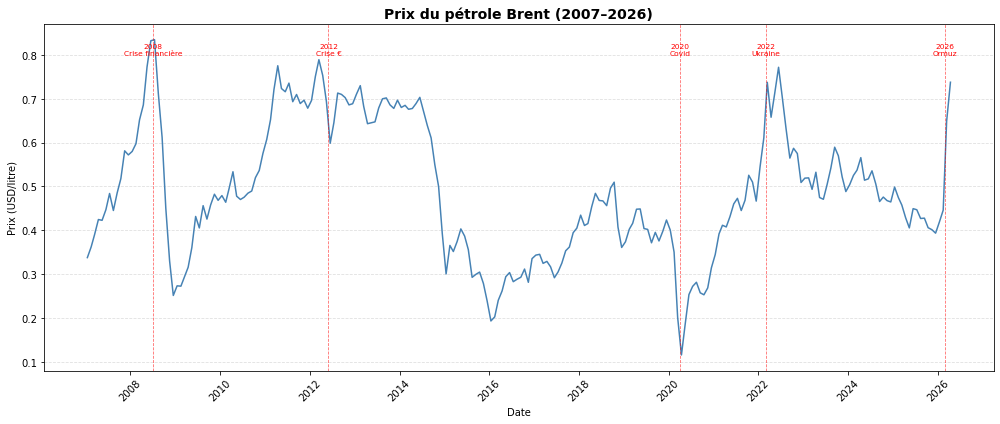

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Chargement
df = pd.read_csv('brent_usd_litre.csv', parse_dates=['Date'])

# Graphique
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['Date'], df['Brent_USD_litre'], color='steelblue', linewidth=1.5)

# Annotations des événements clés (mêmes que ton graphique diesel)
evenements = {
    '2008\nCrise financière': '2008-07-01',
    '2012\nCrise €': '2012-06-01',
    '2020\nCovid': '2020-04-01',
    '2022\nUkraine': '2022-03-01',
    '2026\nOrmuz': '2026-03-01',
}

for label, date in evenements.items():
    ax.axvline(pd.to_datetime(date), color='red', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pd.to_datetime(date), ax.get_ylim()[1] * 0.95, label,
            fontsize=7.5, color='red', ha='center', va='top')

# Mise en forme
ax.set_title('Prix du pétrole Brent (2007–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Prix (USD/litre)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

# Chargement depuis l'onglet DATA(EXR) de la BCE
df_fx = pd.read_excel('taux_de_change.xlsx',
                      sheet_name='DATA(EXR)', header=None)

# La ligne 0 contient les noms de colonnes
df_fx.columns = df_fx.iloc[0]
df_fx = df_fx[1:].reset_index(drop=True)

# Sélection par nom exact (vérification)
print("Colonnes disponibles :", df_fx.columns.tolist())

# Sélection des colonnes utiles
df_fx = df_fx[['DATE', 'OBS.VALUE']].copy()
df_fx.columns = ['Date', 'EUR_USD']

# Conversion et filtre 2007-aujourd'hui
df_fx['Date'] = pd.to_datetime(df_fx['Date'])
df_fx['EUR_USD'] = pd.to_numeric(df_fx['EUR_USD']).round(4)
df_fx = df_fx[df_fx['Date'] >= '2007-01-01'].reset_index(drop=True)

# Export
df_fx.to_csv('eur_usd_bce.csv', index=False)

print(f"{len(df_fx)} observations — de {df_fx['Date'].dt.to_period('M').iloc[0]} à {df_fx['Date'].dt.to_period('M').iloc[-1]}")

Colonnes disponibles : ['DATE', 'TIME PERIOD', 'OBS.VALUE', 'OBS.STATUS', 'OBS.COMMENT', 'SERIES KEY', 'TITLE', 'FREQUENCY', 'FREQUENCY (DESC.)', 'CURRENCY', 'CURRENCY (DESC.)', 'CURRENCY DENOMINATOR', 'CURRENCY DENOMINATOR (DESC.)', 'EXCHANGE RATE TYPE', 'EXCHANGE RATE TYPE (DESC.)', 'SERIES VARIATION - EXR CONTEXT', 'SERIES VARIATION - EXR CONTEXT (DESC.)']
232 observations — de 2007-01 à 2026-04


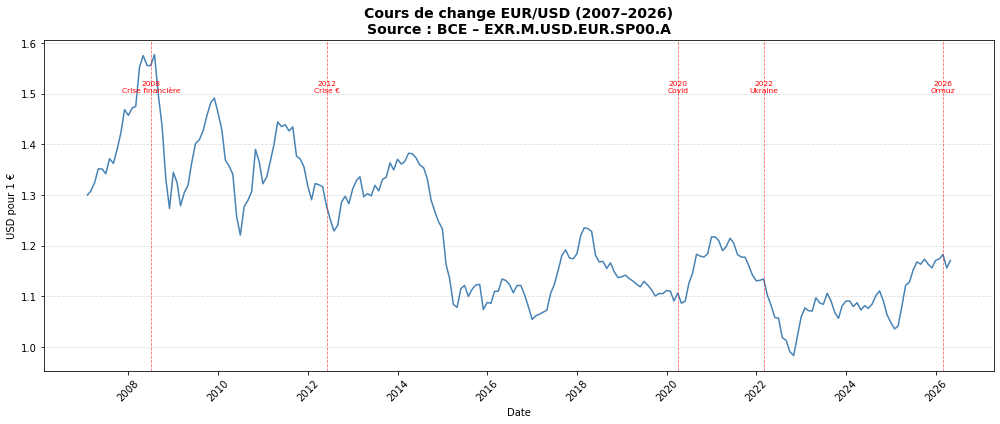

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Chargement
df_fx = pd.read_csv('eur_usd_bce.csv', parse_dates=['Date'])

# Graphique
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_fx['Date'], df_fx['EUR_USD'], color='steelblue', linewidth=1.5)

# Annotations des événements clés
evenements = {
    '2008\nCrise financière': '2008-07-01',
    '2012\nCrise €': '2012-06-01',
    '2020\nCovid': '2020-04-01',
    '2022\nUkraine': '2022-03-01',
    '2026\nOrmuz': '2026-03-01',
}

for label, date in evenements.items():
    ax.axvline(pd.to_datetime(date), color='red', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pd.to_datetime(date), ax.get_ylim()[1] * 0.95, label,
            fontsize=7.5, color='red', ha='center', va='top')

# Mise en forme
ax.set_title('Cours de change EUR/USD (2007–2026)\nSource : BCE – EXR.M.USD.EUR.SP00.A', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('USD pour 1 €')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()